# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
pwd

'/app'

In [2]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [4]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [5]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

runtime minutes

##Inspect Data

In [6]:
df_reviews.head(10)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281
5,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,This is the first movie I've seen from Singapo...,9,pos,1,test,9282
6,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Yes non-Singaporean's can't see what's the big...,9,pos,1,test,9283
7,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,This true story of Carlson's Raiders is more o...,2,neg,0,train,9903
8,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,Should have been titled 'Balderdash!' Little i...,2,neg,0,train,9905
9,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,The movie 'Gung Ho!': The Story of Carlson's M...,4,neg,0,train,9904


In [7]:
df_reviews.shape

(47331, 17)

In [8]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [9]:
df_reviews.describe()

,start_year,is_adult,average_rating,votes,rating,pos,idx
count,47331.000000,47331.000000,47329.000000,4.732900e+04,47331.000000,47331.000000,47331.000000
mean,1989.631235,0.001732,5.998278,2.556292e+04,5.484608,0.498954,6279.697999
std,19.600364,0.041587,1.494289,8.367004e+04,3.473109,0.500004,3605.702545
min,1894.000000,0.000000,1.400000,9.000000e+00,1.000000,0.000000,0.000000
25%,1982.000000,0.000000,5.100000,8.270000e+02,2.000000,0.000000,3162.000000
50%,1998.000000,0.000000,6.300000,3.197000e+03,4.000000,0.000000,6299.000000
75%,2004.000000,0.000000,7.100000,1.397400e+04,9.000000,1.000000,9412.000000
max,2010.000000,1.000000,9.700000,1.739448e+06,10.000000,1.000000,12499.000000



The average IMDb movie rating is approximately:
6.0, which indicates the dataset contains a mix of highly rated and poorly rated films.


The average rating of mean 5.99, median of 6.3, min 1.4, and max 9.7, indicate that the dataset contains a mix of highly rated and poorly rated films.

The number of votes is skewed:

Median votes = 3,197
Mean votes = 25,563
Max votes = 1,739,448

This suggests a few films receive more voting while most films receive relatively few votes.

In [10]:
df_reviews.isna().sum()


tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64

In [11]:
df_reviews.duplicated().sum()

0

- Average_rating and votes have 2 missing
- Review has NO missing values
- Pos has NO missing values
- No duplicat
- Our selected fields (review, pos, ds-part) do not have missing data and the date type is okey.
- Since the critical columns contain no missing values, no imputation is required for the task.

## EDA

Let's check the number of movies and reviews over years.

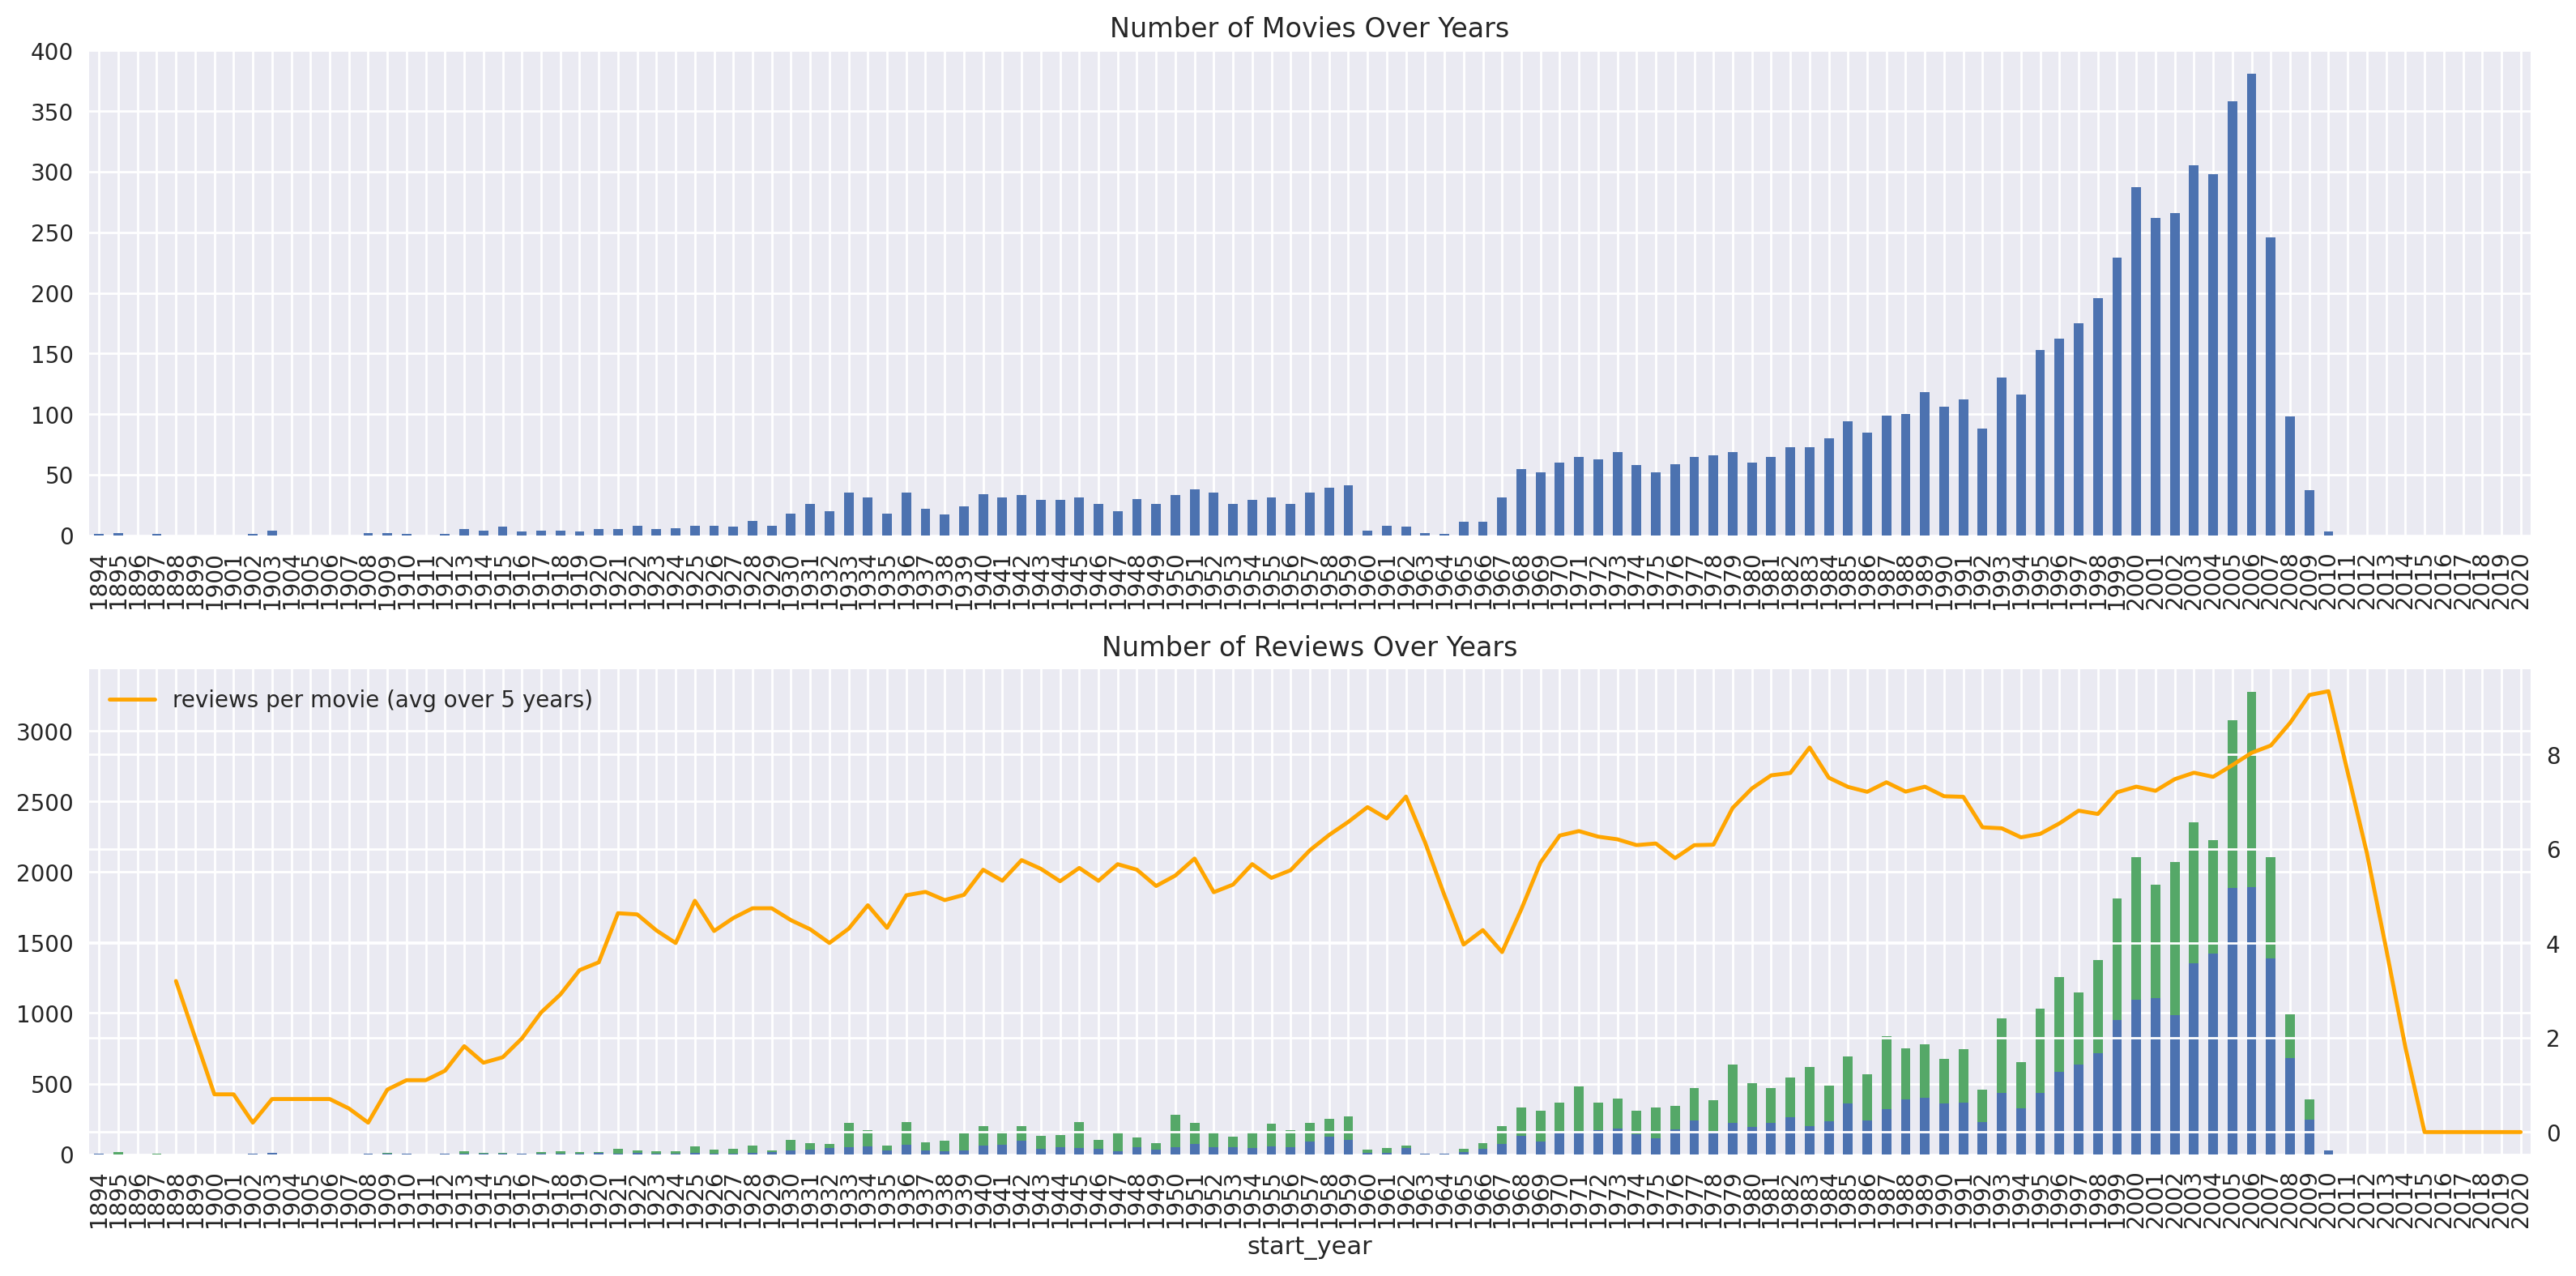

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

The number of movies represented in the dataset increases substantially after the 1980s and peaks around the 2000s.
The dataset is dominated by films released between the 1970s and 2009.

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

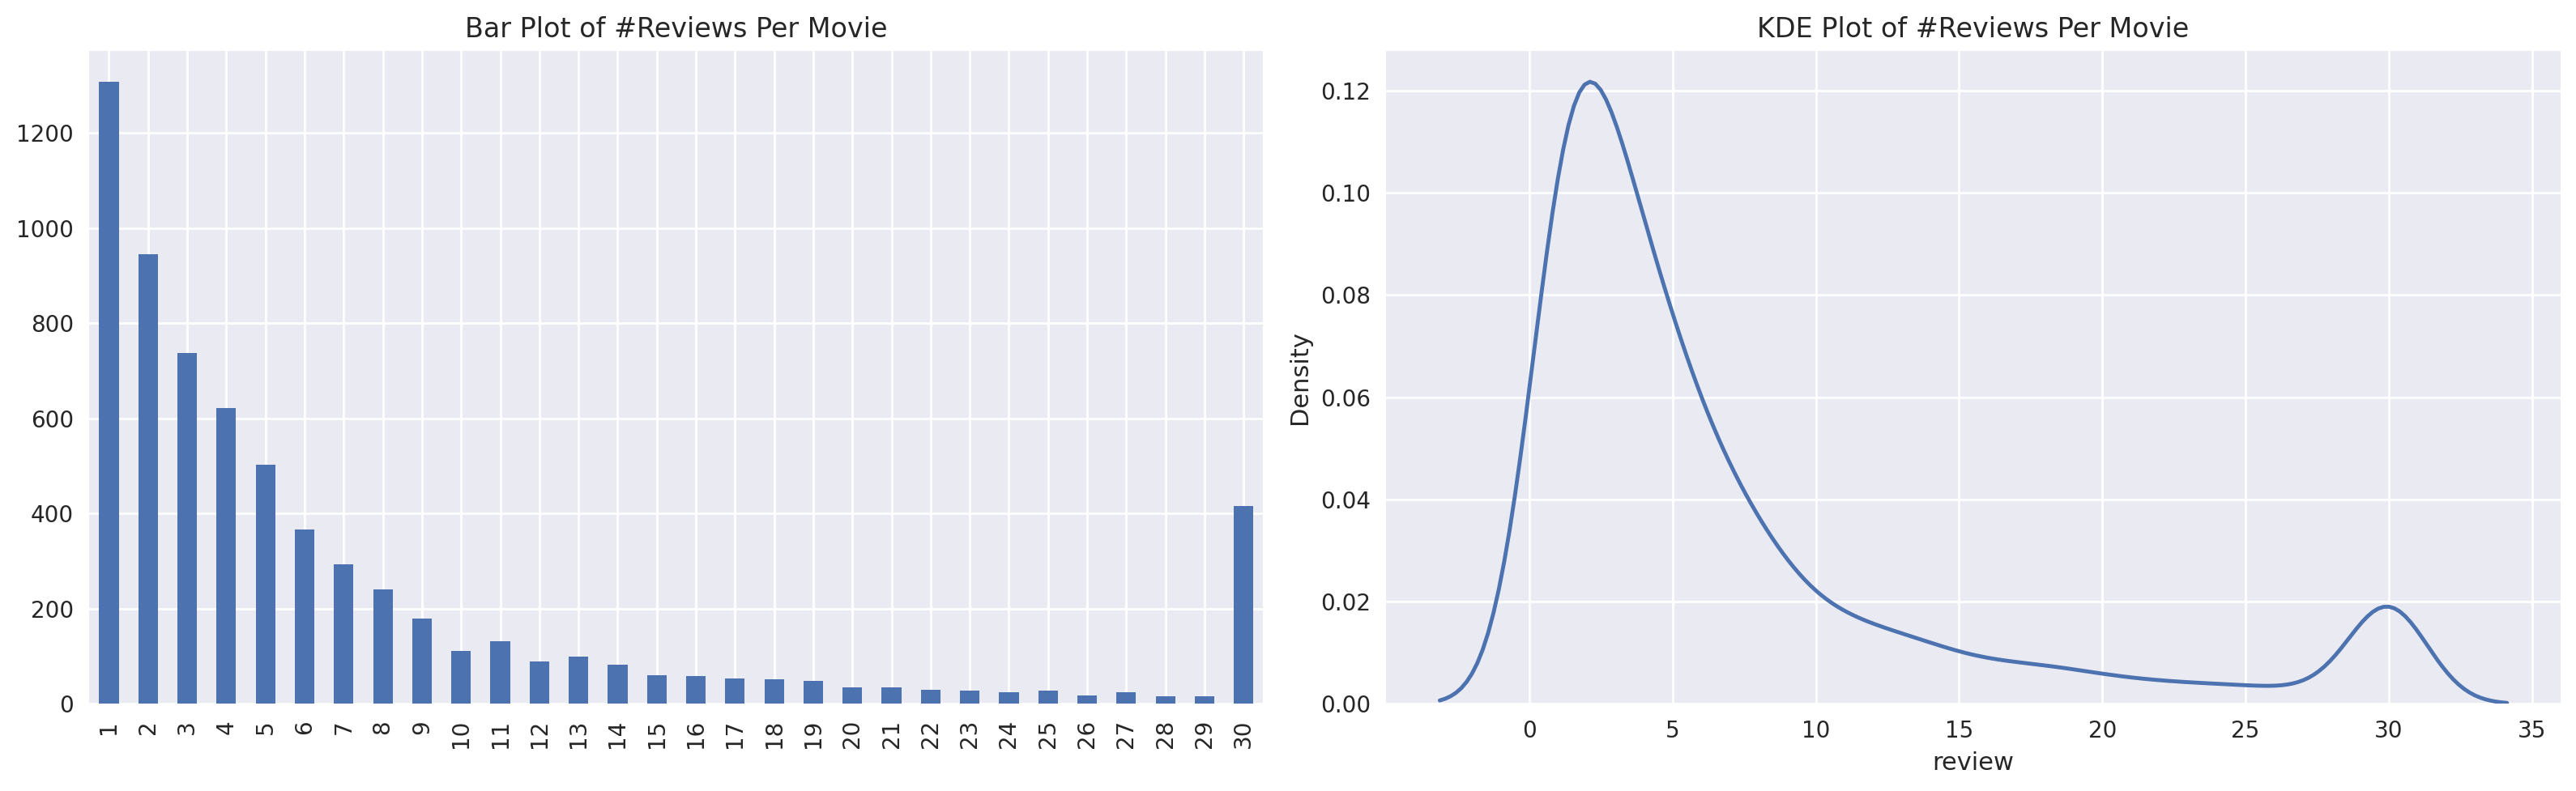

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [14]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

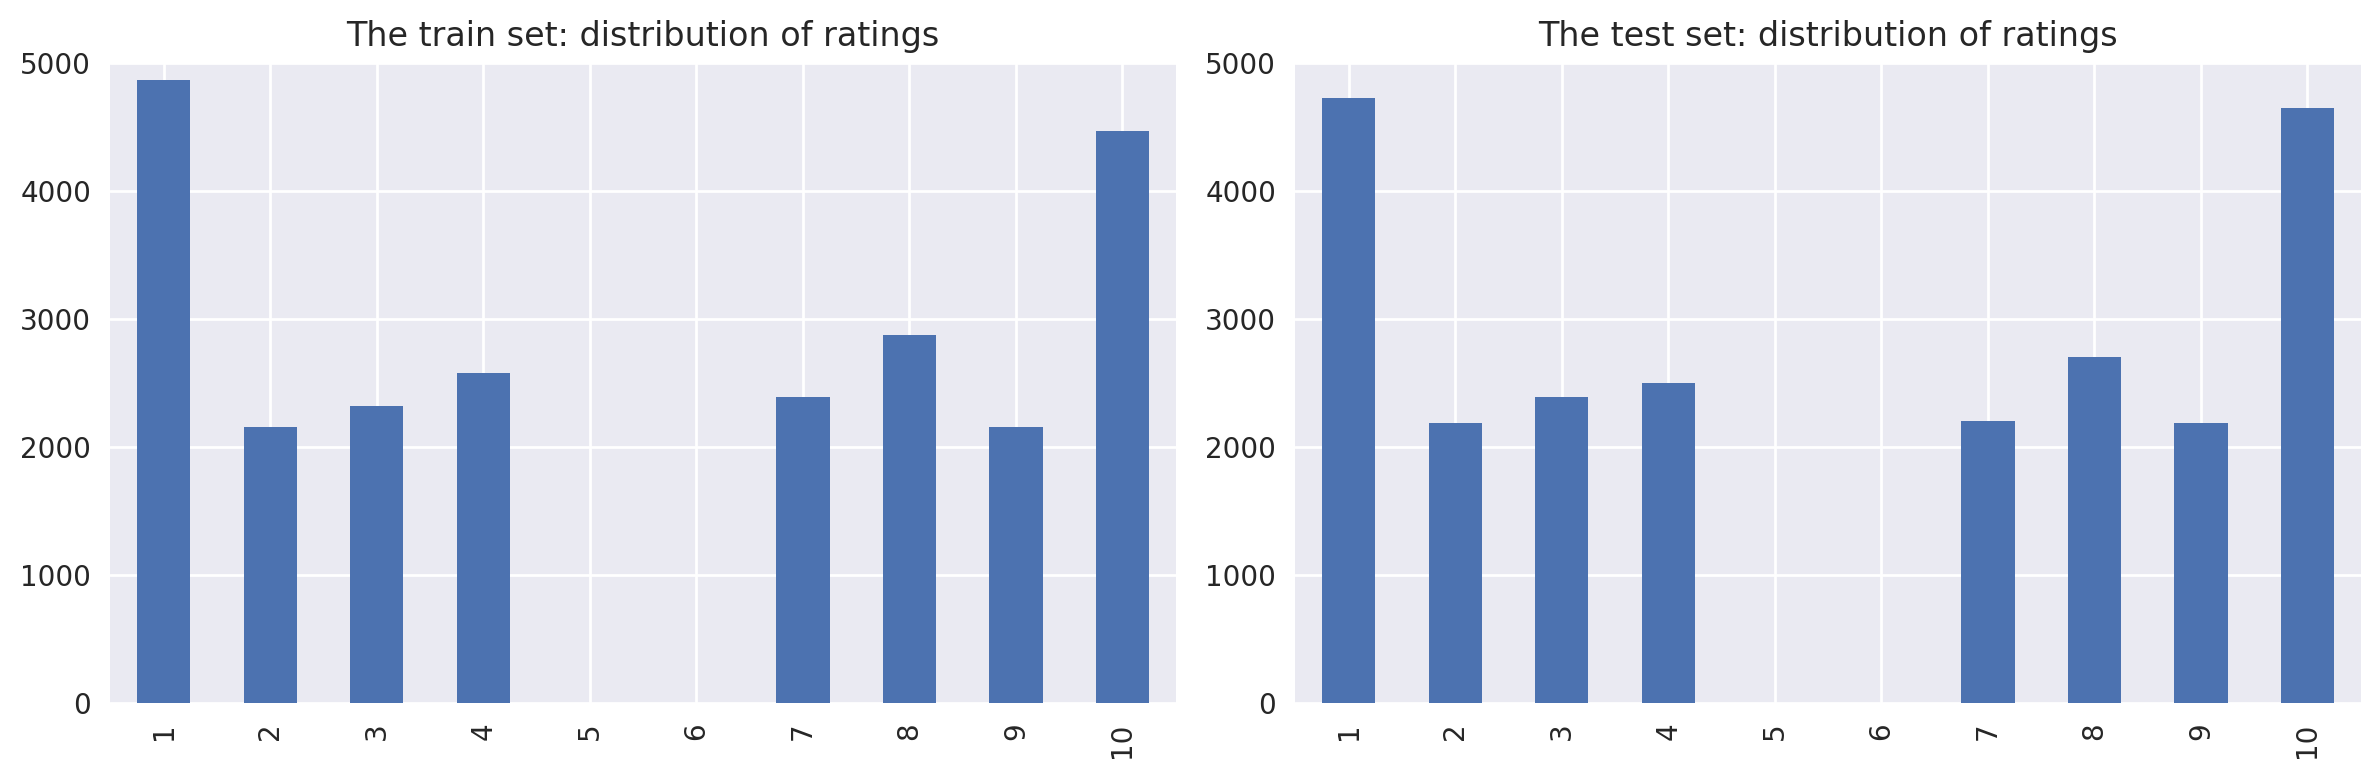

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


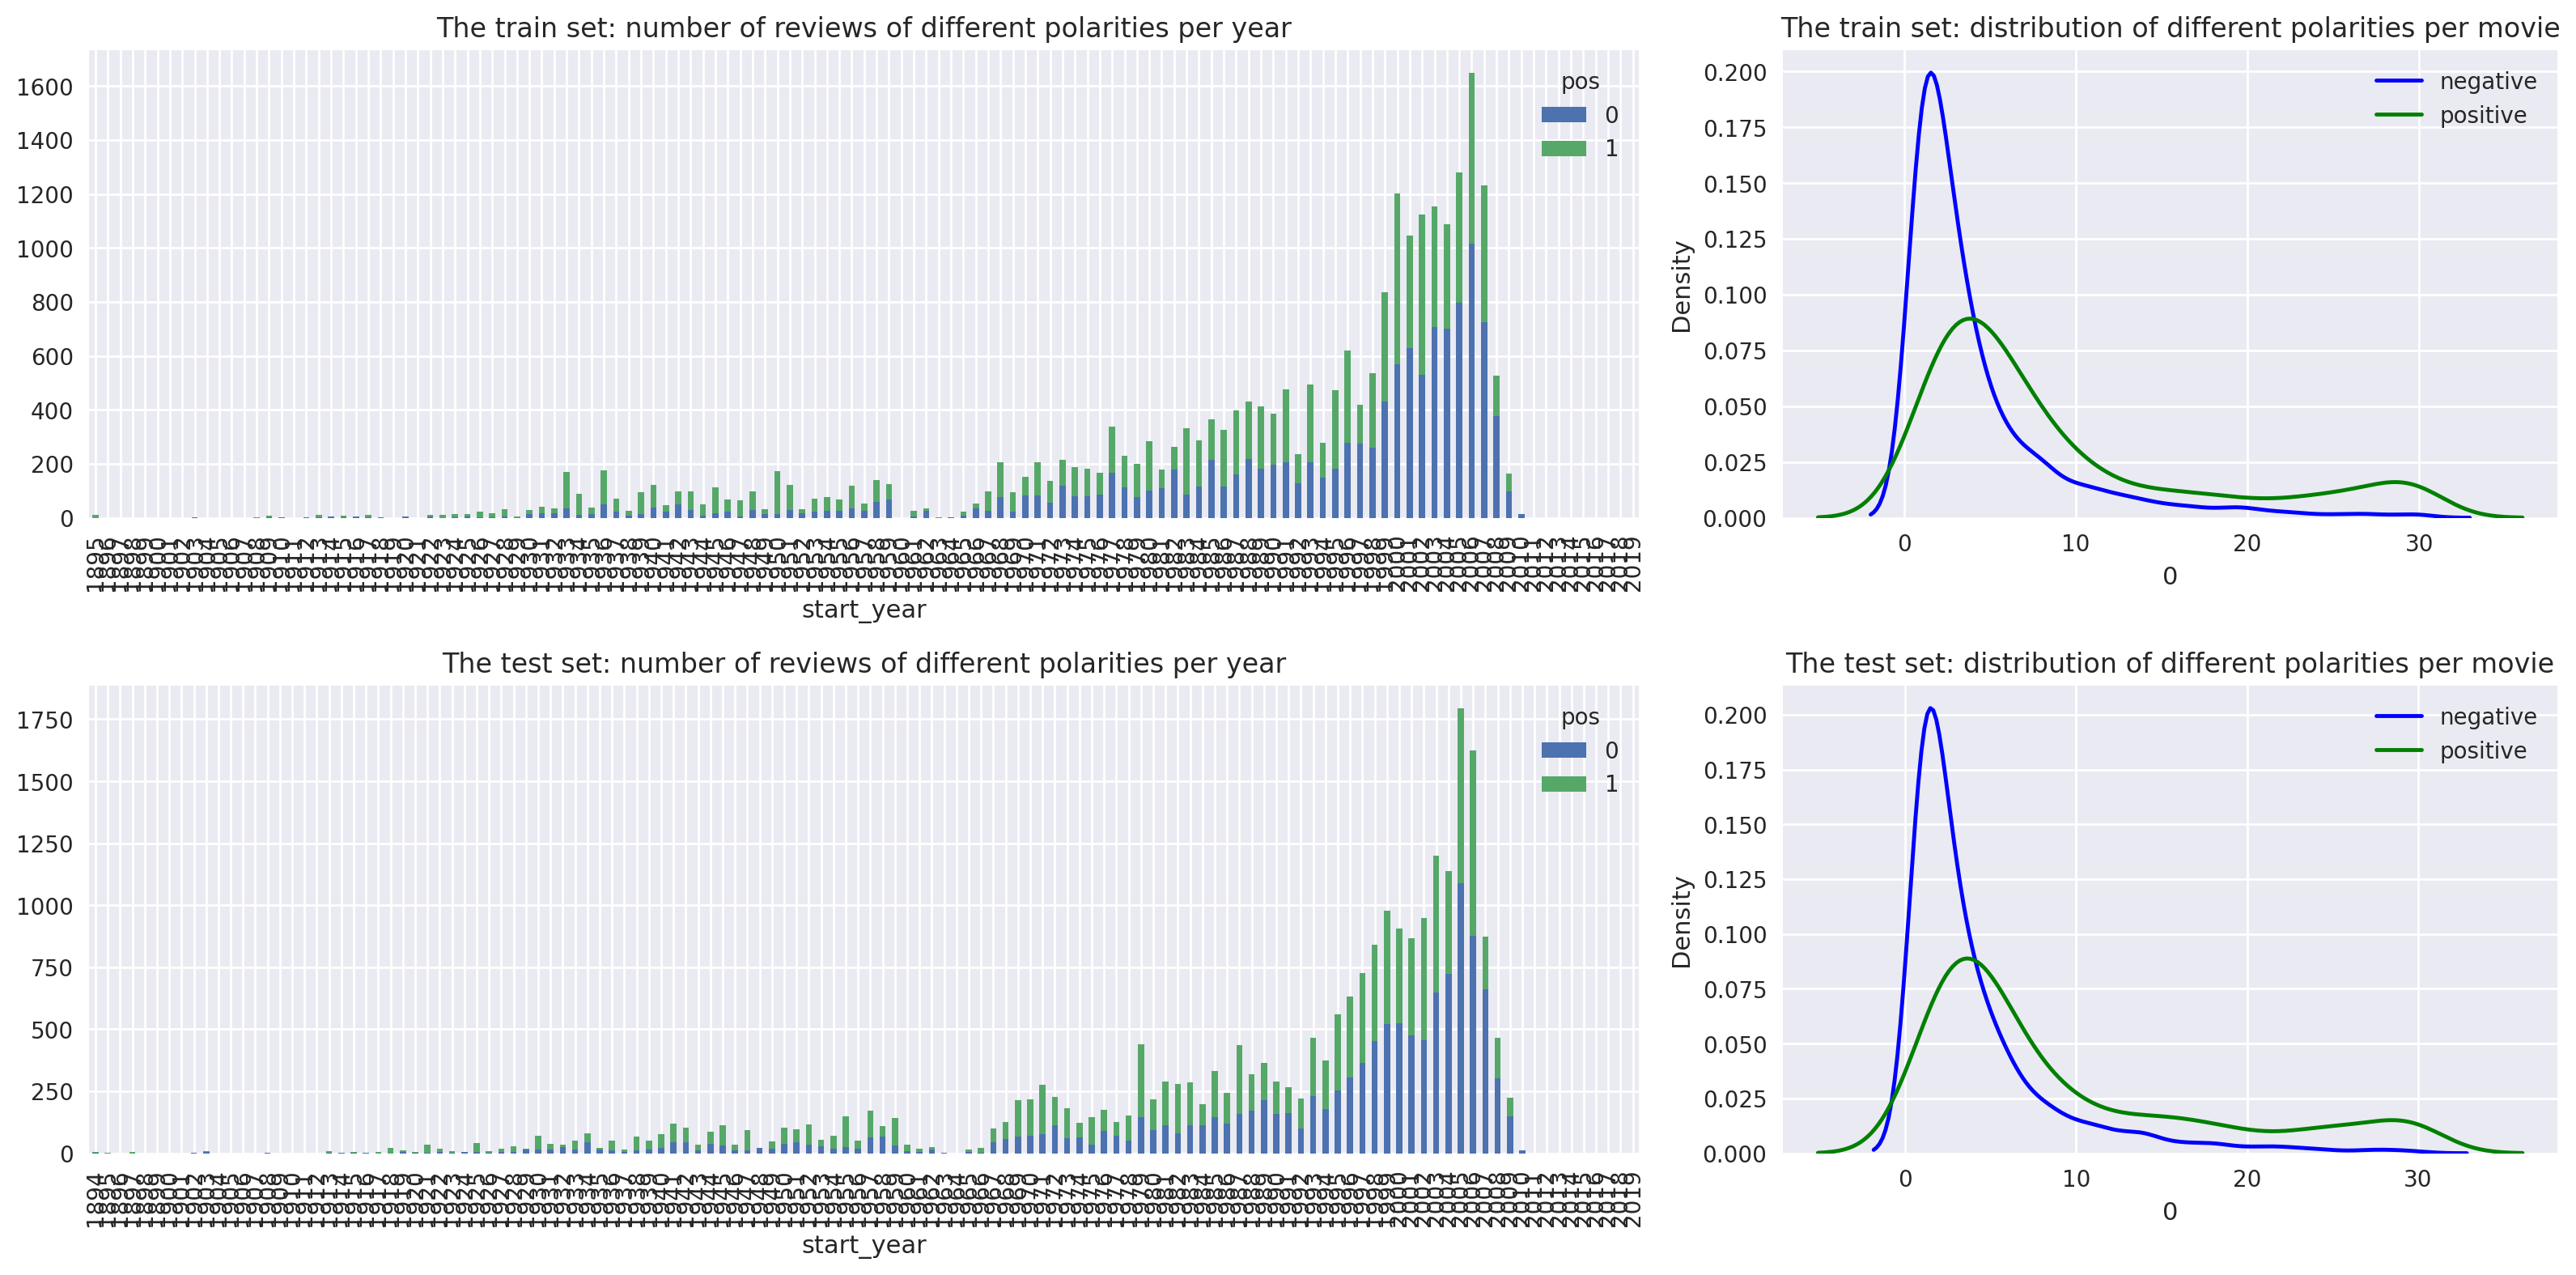

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

Validating Class Balance Analysis

In [17]:
df_reviews['pos'].value_counts(normalize=True)

0    0.501046
1    0.498954
Name: pos, dtype: float64

The number of movies represented in the dataset increases substantially after the 1980s and peaks around the 2000s.
The dataset is dominated by films released between the 1970s and 2009.
This creates a long right tail.



The distribution is highly right-skewed. Most films contribute only a few reviews, while a small number of popular films contribute many reviews. The review count per movie is not evenly distributed and exhibits a strong positive skew.


The distributions of train - test data set are identitical. The rating distribution is more concentrated at the estreem end, with many users assigning either very low or very high ratings.. while middle ratings occur less frequently.

This is common in review datasets because people tend to write reviews when they strongly like or dislike a movie.

Both positive and negative review counts increase over time. Positive reviews appear slightly more common in many years. The train and test distributions are very similar. The target classes are well balanced. Approximately half of the reviews are positive and half are negative. Therefore, class imbalance is not expected to significantly affect model performance, and no resampling techniques are required.
This suggest that model evaluation will be reliable and representative.
    

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [18]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [19]:
import re

def clear_text(text):
    
    text = text.lower()

    text = re.sub(r'[^a-z\s]', ' ', text)

    text = ' '.join(text.split())

    return text

In [20]:
df_reviews['review_norm'] = df_reviews['review'].apply(clear_text) # <put your code here>

In [21]:
df_reviews[['review', 'review_norm']].head()

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i m totally agree with garryjohal from singapo...


## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [22]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

### Model 0 - Constant

In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
model_0 = DummyClassifier(
    strategy='most_frequent'
)

In [25]:
model_0.fit(
    np.zeros((len(train_target),1)),
    train_target
)

DummyClassifier(strategy='most_frequent')

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


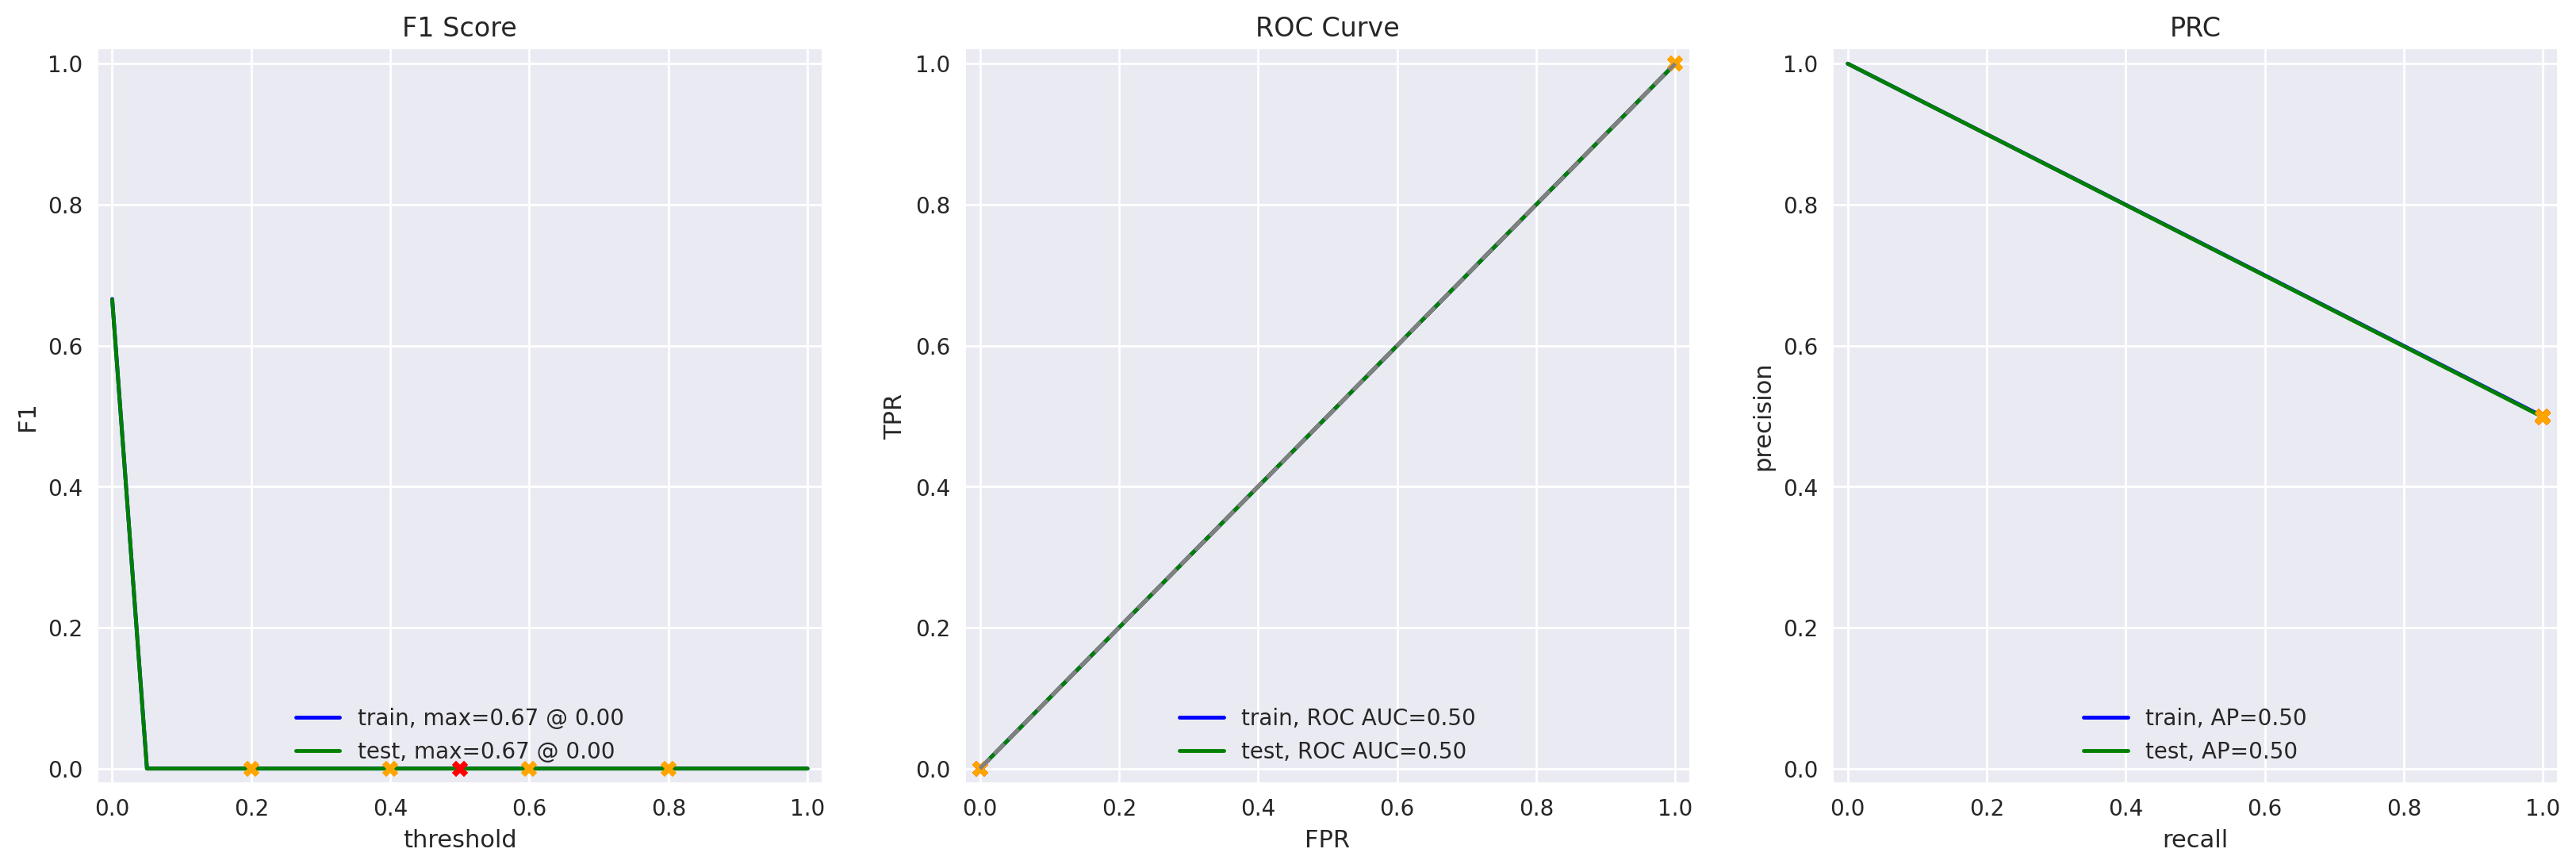

In [26]:
evaluate_model(
    model_0,
    np.zeros((len(train_target),1)),
    train_target,
    np.zeros((len(test_target),1)),
    test_target
)

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [27]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords



Create vectorizer:

In [28]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

Fit:

In [29]:
train_features_1 = tfidf.fit_transform(
    df_reviews_train['review_norm']
)

test_features_1 = tfidf.transform(
    df_reviews_test['review_norm']
)
print(train_features_1.shape)

(23796, 10000)


#Logistic Regression

In [30]:


#Import:

from sklearn.linear_model import LogisticRegression

#Create:

model_1 = LogisticRegression(
    max_iter=1000
)



In [31]:
#Train:

model_1.fit(
    train_features_1,
    train_target
)

LogisticRegression(max_iter=1000)

Evaluate

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


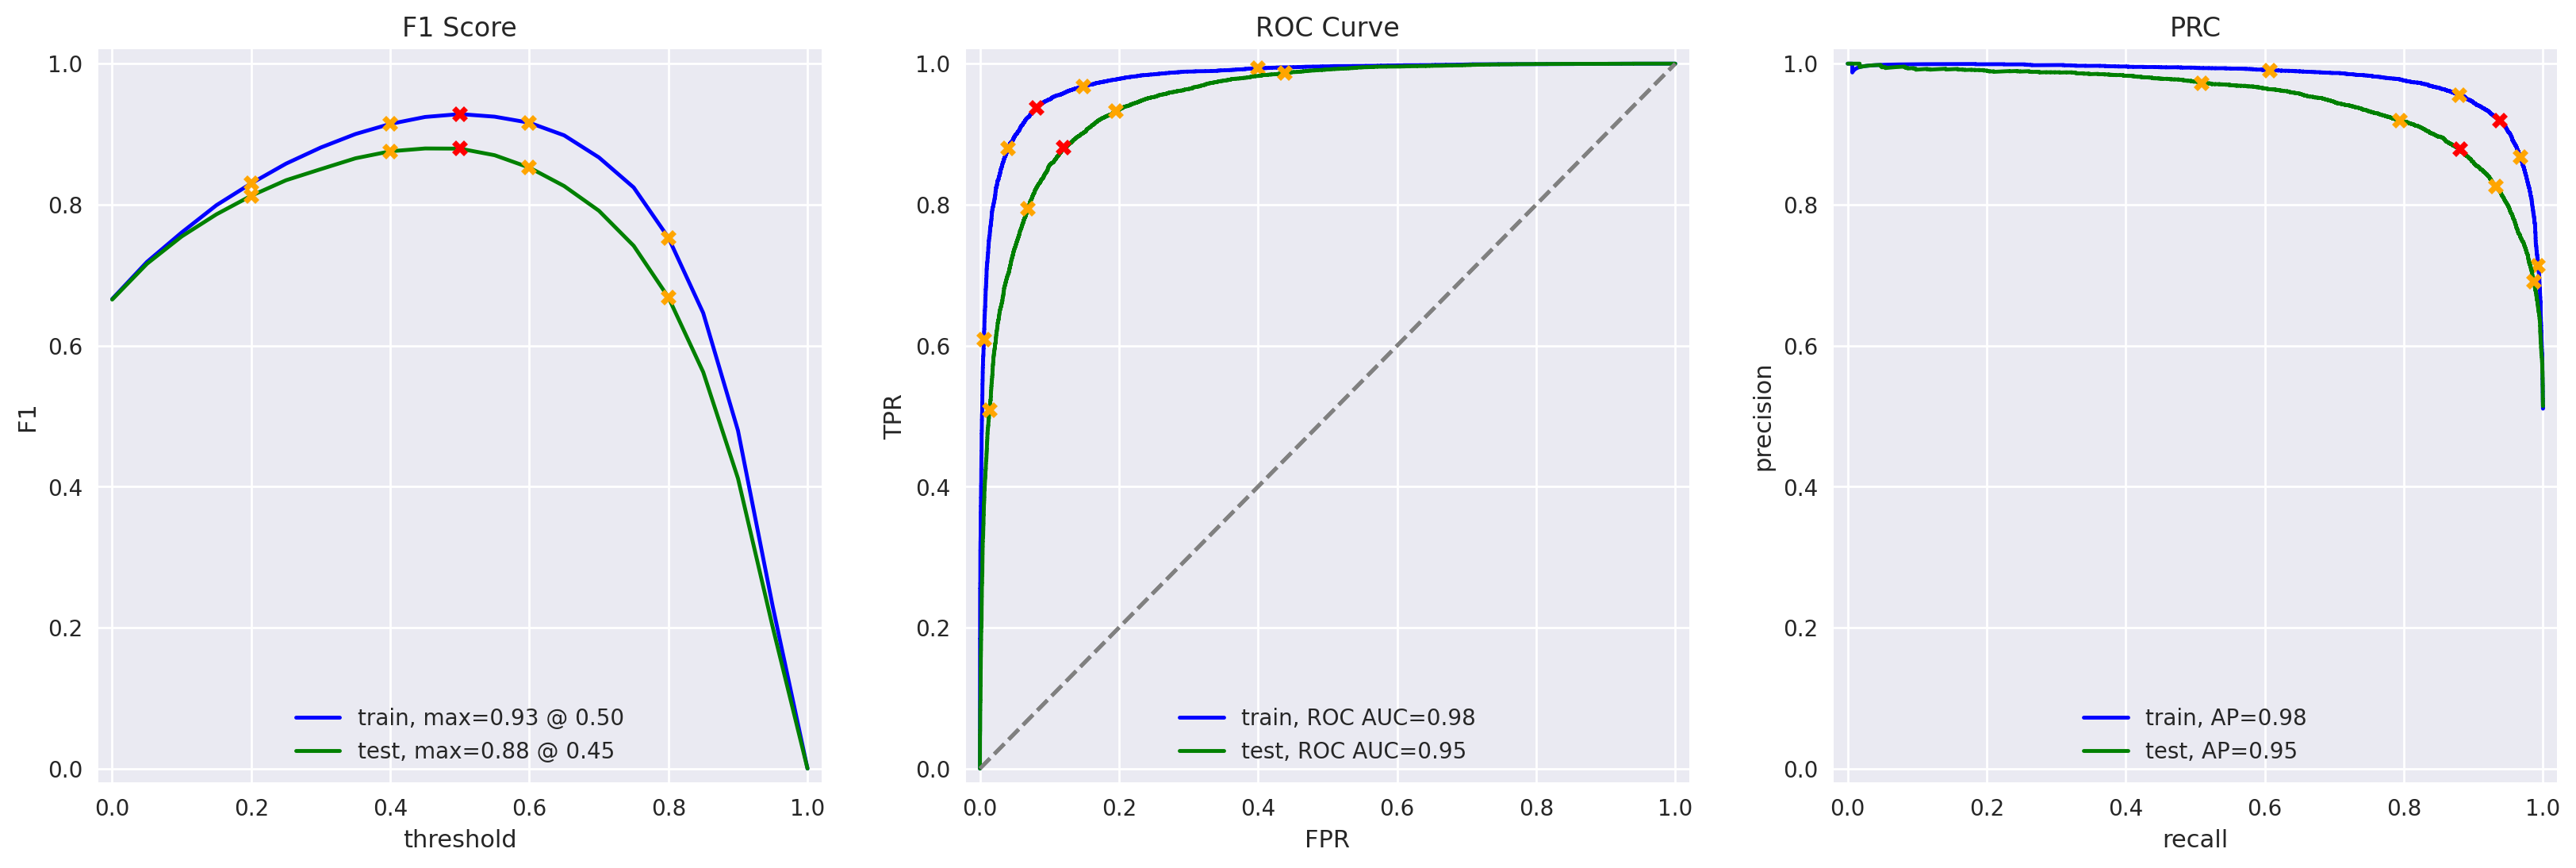

In [32]:

evaluate_model(
    model_1,
    train_features_1,
    train_target,
    test_features_1,
    test_target
)

In [33]:
### Model 1 - NLTK, TF-IDF and LR

### Model 3 - spaCy, TF-IDF and LR

In [35]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
print ('done')

done


In [36]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    #tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)
print ('done')

done



train_corpus_3 = df_reviews_train[
    'review_norm'
].apply(text_preprocessing_3)

test_corpus_3 = df_reviews_test[
    'review_norm'
].apply(text_preprocessing_3)
print ('done')



In [37]:
train_corpus_3 = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)
test_corpus_3 = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

Lemmatize Reviews

TF-IDF

In [38]:

tfidf_3 = TfidfVectorizer(
    max_features=10000
)


In [39]:
train_features_3 = tfidf_3.fit_transform(
    train_corpus_3
)



In [40]:
test_features_3 = tfidf_3.transform(
    test_corpus_3
)
print ('done')

done


Logistic Regression

In [41]:

model_3 = LogisticRegression(
    max_iter=1000
)



In [42]:
#Train:

model_3.fit(
    train_features_3,
    train_target
)

print ('done')

done


Evaluate:

          train  test
Accuracy   0.92  0.88
F1         0.92  0.87
APS        0.98  0.94
ROC AUC    0.98  0.95


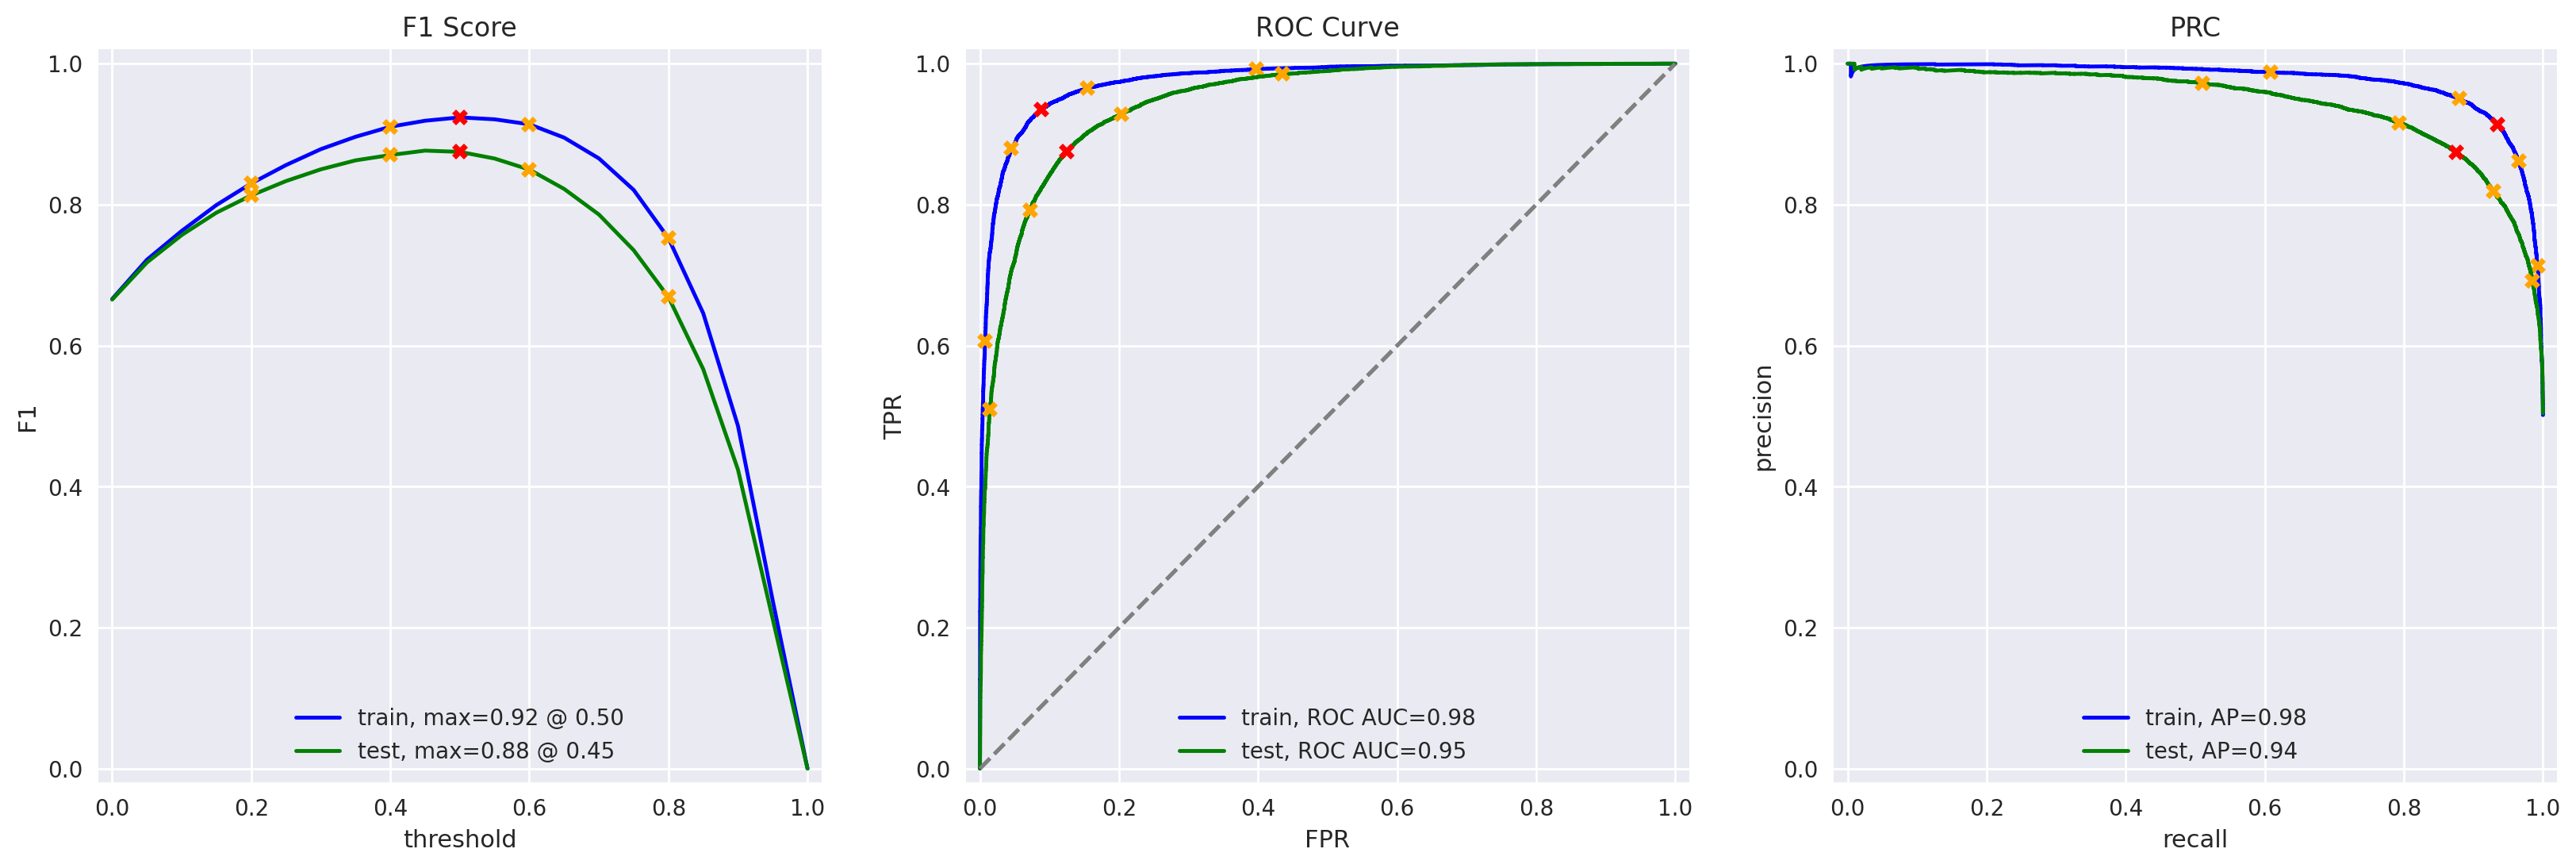

In [43]:
evaluate_model(
    model_3,
    train_features_3,
    train_target,
    test_features_3,
    test_target
)

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [44]:
from lightgbm import LGBMClassifier

In [45]:
#Create Model
model_4 = LGBMClassifier(
    n_estimators=100
)

Train

In [46]:
#Convert to dense arrays:

train_features_4 = train_features_3
test_features_4 = test_features_3




          train  test
Accuracy   0.91  0.85
F1         0.91  0.86
APS        0.97  0.93
ROC AUC    0.97  0.93


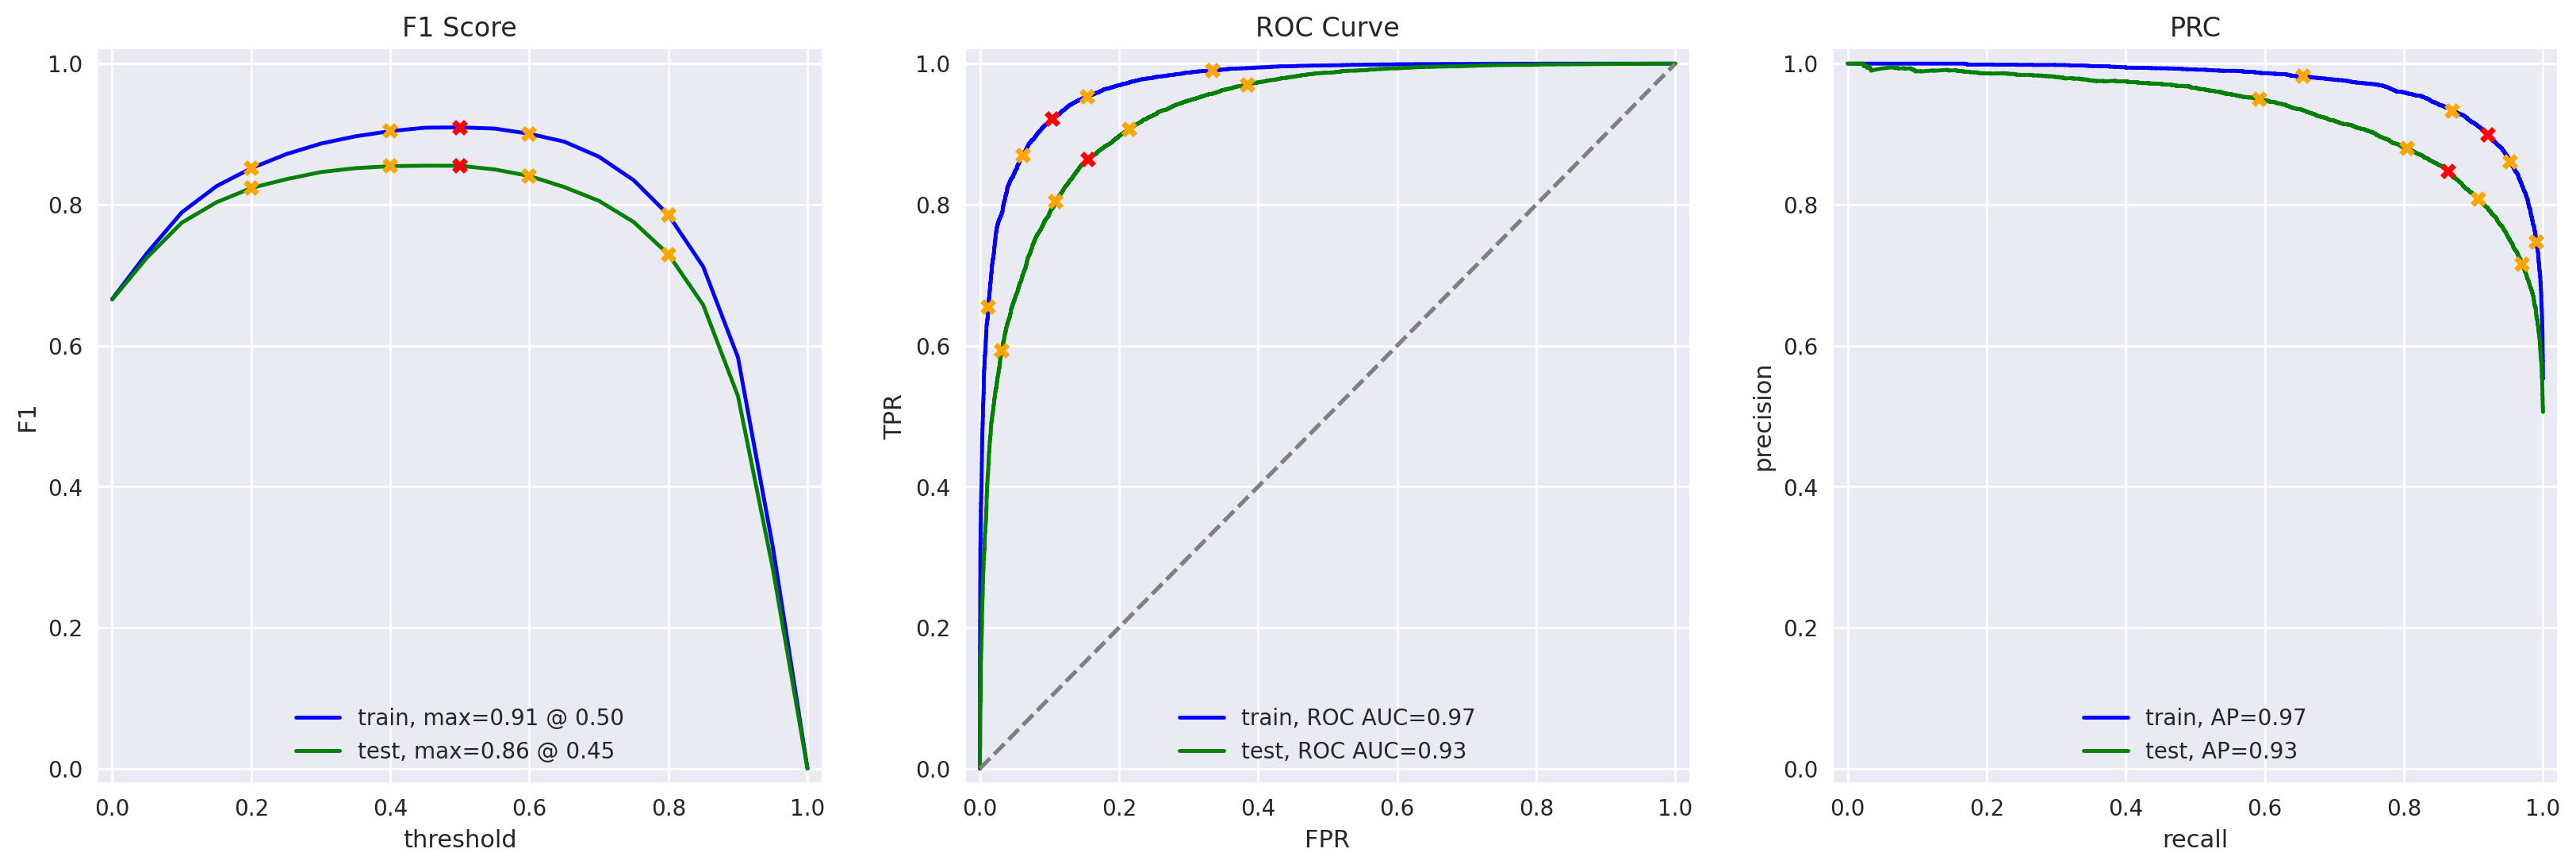

In [47]:
from lightgbm import LGBMClassifier


model_4 = LGBMClassifier(n_estimators=100, random_state=12345)

model_4.fit(train_features_4, train_target)

evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

In [48]:
#Train:

model_4.fit(
    train_features_4,
    train_target
)

LGBMClassifier(random_state=12345)

Evaluate

          train  test
Accuracy   0.91  0.85
F1         0.91  0.86
APS        0.97  0.93
ROC AUC    0.97  0.93


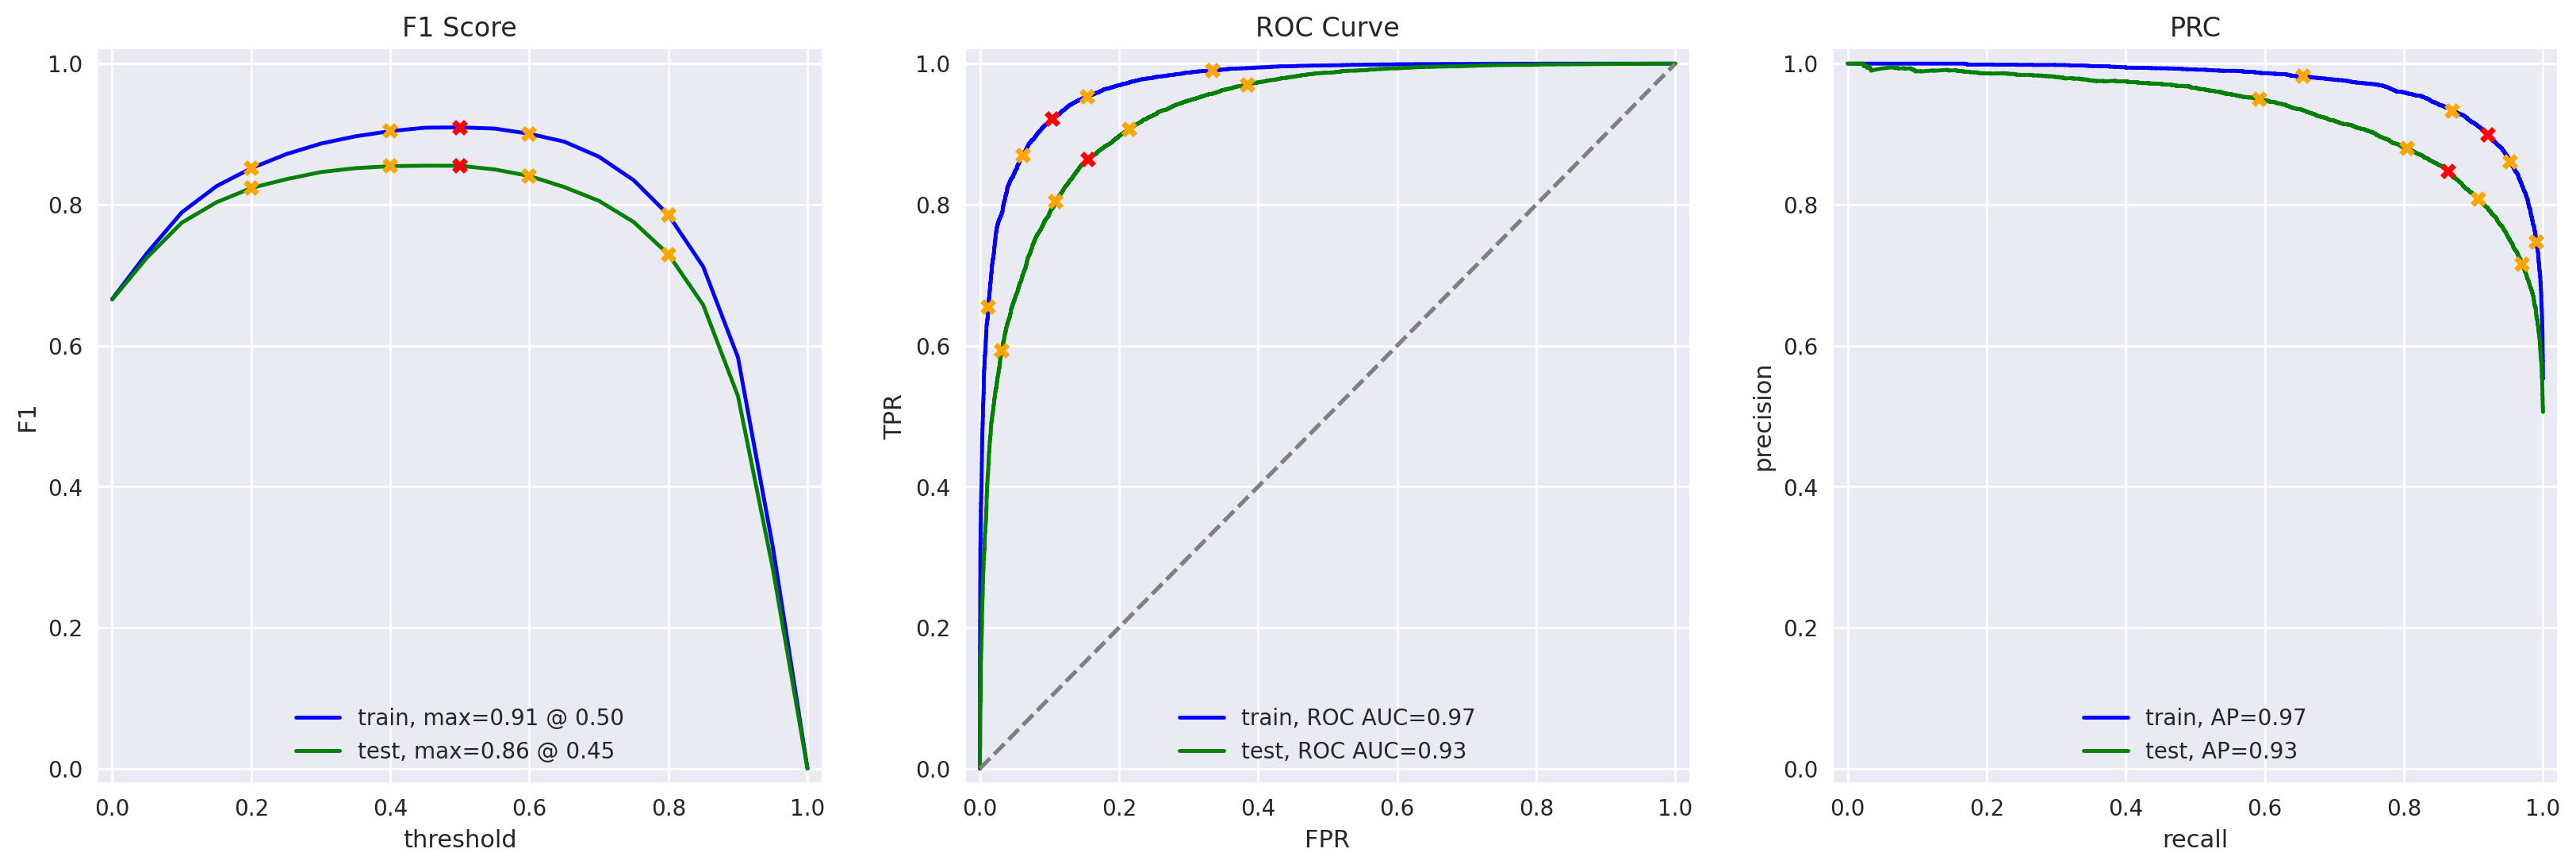

In [49]:

evaluate_model(
    model_4,
    train_features_4,
    train_target,
    test_features_4,
    test_target
)

COMPARE RESULTS

In [50]:
#Create a summary table.

from sklearn import metrics

def get_test_metrics(model, test_features, test_target):
    pred = model.predict(test_features)
    proba = model.predict_proba(test_features)[:, 1]
    return {
        'F1': metrics.f1_score(test_target, pred),
        'APS': metrics.average_precision_score(test_target, proba),
        'ROC AUC': metrics.roc_auc_score(test_target, proba),
    }

metrics_1 = get_test_metrics(model_1, test_features_1, test_target)
metrics_3 = get_test_metrics(model_3, test_features_3, test_target)
metrics_4 = get_test_metrics(model_4, test_features_4, test_target)

results = pd.DataFrame({
    'Model': ['TFIDF + LR', 'spaCy + TFIDF + LR', 'spaCy + TFIDF + LGBM'],
    'F1': [metrics_1['F1'], metrics_3['F1'], metrics_4['F1']],
    'APS': [metrics_1['APS'], metrics_3['APS'], metrics_4['APS']],
    'ROC AUC': [metrics_1['ROC AUC'], metrics_3['ROC AUC'], metrics_4['ROC AUC']]
})
print (results)

                  Model        F1       APS   ROC AUC
0            TFIDF + LR  0.879438  0.947111  0.949309
1    spaCy + TFIDF + LR  0.874835  0.943623  0.946178
2  spaCy + TFIDF + LGBM  0.855129  0.930060  0.932450


In [51]:
print (results)

                  Model        F1       APS   ROC AUC
0            TFIDF + LR  0.879438  0.947111  0.949309
1    spaCy + TFIDF + LR  0.874835  0.943623  0.946178
2  spaCy + TFIDF + LGBM  0.855129  0.930060  0.932450


In [52]:
#Sort values
results.sort_values(
    by='F1',
    ascending=False
)

,Model,F1,APS,ROC AUC
0,TFIDF + LR,0.879438,0.947111,0.949309
1,spaCy + TFIDF + LR,0.874835,0.943623,0.946178
2,spaCy + TFIDF + LGBM,0.855129,0.930060,0.932450


Example Review:

In [53]:
my_reviews = [
    "This movie was fantastic and I loved it.",
    "Terrible acting and boring plot.",
    "One of the best films I have ever seen.",
    "Waste of time and money."
]

Clean the review

In [54]:
my_reviews_norm = [
    clear_text(x)
    for x in my_reviews
]

Vectorize:

In [55]:
my_features_1 = tfidf.transform(
    my_reviews_norm
)

#Predict:

model_1.predict(my_features_1)

array([1, 0, 1, 0])

#Interpretation:
1 = positive
0 = negative


Model 1 pediction

In [56]:
#Transform:

my_reviews_norm = [clear_text(review) for review in my_reviews]



my_features_1 = tfidf.transform(my_reviews_norm)

pred_1 = model_1.predict(my_features_1)

print(pred_1)

[1 0 1 0]


Model 3 Predictions

In [57]:
my_reviews_spacy = [
    text_preprocessing_3(review)
    for review in my_reviews_norm
]


my_features_3 = tfidf_3.transform(my_reviews_spacy)

pred_3 = model_3.predict(my_features_3)

print(pred_3)

[1 0 1 0]


Model 4 Predictions

In [58]:
my_features_4 = tfidf_3.transform(my_reviews_spacy)

pred_4 = model_4.predict(
    my_features_4.toarray()
)

print(pred_4)

[1 0 1 0]


Compare Results

In [59]:

comparison = pd.DataFrame({
    'Review': my_reviews,
    'Model_1': pred_1,
    'Model_3': pred_3,
    'Model_4': pred_4
})

print (comparison)

                                     Review  Model_1  Model_3  Model_4
0  This movie was fantastic and I loved it.        1        1        1
1          Terrible acting and boring plot.        0        0        0
2   One of the best films I have ever seen.        1        1        1
3                  Waste of time and money.        0        0        0


Review	Predicted Sentiment

All the three models were able to make the right predictions. Asigning one as posetive review and o as negative review.

"This movie was amazing. Great acting and story." :	Positive
"Terrible film. Waste of time." : Negative
"One of the best movies I have ever seen.": Positive
"Awful plot and boring characters."	: Negative

**Findings:**

The goal of this project was to build a model that could classify IMDB movie reviews as either positive or negative. All three models met the required F1 score of at least 0.85, showing that they performed well on the sentiment classification task.

Among the three models, TF-IDF + Logistic Regression achieved the best overall performance, with the highest F1 score, APS, and ROC AUC. spaCy + TF-IDF + Logistic Regression performed almost as well, suggesting that adding spaCy preprocessing did not significantly improve the results. spaCy + TF-IDF + LightGBM had the lowest scores, although it still met the project requirement.

To further test the models, I used four custom movie reviews. All three models correctly classified each review as either positive or negative, showing that they generalized well to new, unseen text.

Overall, TF-IDF + Logistic Regression was the best-performing model. It achieved the highest performance, making it the preferred choice for this sentiment analysis task.

**Challenge:** One of the biggest challenges I faced was that the notebook kept crashing while training the LightGBM model. After some investigation and feedback from the reviewer, I discovered that converting the TF-IDF matrices to dense arrays was causing the memory issue. Keeping the matrices in their sparse format resolved the problem, and I was able to train and evaluate the model successfully.

**Recommendation:**
For future improvements, I would explore more feature engineering, hyperparameter tuning, and advanced NLP models to see if the performance can be improved further. I would also test the models on larger and more varied datasets to check how well they perform on new reviews. Keeping TF-IDF data in sparse format is also recommended, as it helps reduce memory usage when working with large text datasets.